In [17]:
import pandas as pd
train_df = pd.read_csv("churn-bigml-80.csv")
test_df = pd.read_csv("churn-bigml-20.csv")

print("Training set:", train_df.shape)
print("Testing set:", test_df.shape)
train_df.head()

Training set: (2666, 20)
Testing set: (667, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [18]:
print(train_df["International plan"].unique())
print(train_df["Voice mail plan"].unique())
print(train_df["State"].unique(), "unique states")


['No' 'Yes']
['Yes' 'No']
['KS' 'OH' 'NJ' 'OK' 'AL' 'MA' 'MO' 'WV' 'RI' 'IA' 'MT' 'ID' 'VT' 'VA'
 'TX' 'FL' 'CO' 'AZ' 'NE' 'WY' 'IL' 'NH' 'LA' 'GA' 'AK' 'MD' 'AR' 'WI'
 'OR' 'DE' 'IN' 'UT' 'CA' 'SD' 'NC' 'WA' 'MN' 'NM' 'NV' 'DC' 'NY' 'KY'
 'ME' 'MS' 'MI' 'SC' 'TN' 'PA' 'HI' 'ND' 'CT'] unique states


In [19]:

for df in [train_df, test_df]:
    df["International plan"] = df["International plan"].map({"Yes": 1, "No": 0})
    df["Voice mail plan"] = df["Voice mail plan"].map({"Yes": 1, "No": 0})

    df["Churn"] = df["Churn"].astype(int)

train_df[["International plan", "Voice mail plan", "Churn"]].head()

,International plan,Voice mail plan,Churn
0,0,1,0
1,0,1,0
2,0,0,0
3,1,0,0
4,1,0,0


In [20]:
train_df = pd.get_dummies(train_df, columns=["State"], drop_first=True)
test_df = pd.get_dummies(test_df, columns=["State"], drop_first=True)

print(train_df.shape)
print(test_df.shape)


(2666, 69)
(667, 69)


In [21]:

x_train = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"]

x_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(2666, 68) (2666,)
(667, 68) (667,)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

print("Scaled training shape:", x_train_scaled.shape)

Scaled training shape: (2666, 68)


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

log_reg = LogisticRegression(max_iter=1000, random_state=42)
tree = DecisionTreeClassifier(random_state=42)
forest = RandomForestClassifier(random_state=42)


log_reg.fit(x_train_scaled, y_train)
tree.fit(x_train_scaled, y_train)
forest.fit(x_train_scaled, y_train)

print("All three models trained successfully!")

All three models trained successfully!


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": tree,
    "Random Forest": forest
}

for name, model in models.items():
    y_pred = model.predict(x_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{name}")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1-score:  {f1:.3f}")


Logistic Regression
  Accuracy:  0.859
  Precision: 0.511
  Recall:    0.253
  F1-score:  0.338

Decision Tree
  Accuracy:  0.928
  Precision: 0.742
  Recall:    0.758
  F1-score:  0.750

Random Forest
  Accuracy:  0.945
  Precision: 0.968
  Recall:    0.632
  F1-score:  0.764


In [25]:
from sklearn.model_selection import GridSearchCV

# Define a small grid of hyperparameters to try
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

# Grid search tries every combination and finds the best one, using cross-validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    scoring="recall",   # optimize specifically for recall, since that's our priority
    cv=3
)

grid_search.fit(x_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated recall:", grid_search.best_score_)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validated recall: 0.5873981315841781


In [26]:
# Use the best model found by grid search to predict on the real test set
best_forest = grid_search.best_estimator_
y_pred_best = best_forest.predict(x_test_scaled)

print("Tuned Random Forest — Test Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_best):.3f}")
print(f"  Precision: {precision_score(y_test, y_pred_best):.3f}")
print(f"  Recall:    {recall_score(y_test, y_pred_best):.3f}")
print(f"  F1-score:  {f1_score(y_test, y_pred_best):.3f}")

Tuned Random Forest — Test Set Performance:
  Accuracy:  0.945
  Precision: 0.968
  Recall:    0.632
  F1-score:  0.764


In [27]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

print("NLTK resources downloaded successfully!")

NLTK resources downloaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [28]:
import pandas as pd

df = pd.read_csv("sentiment_cleaned.csv")
print(df.shape)
df.head()

(710, 13)


,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning.,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway!,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight.,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [29]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'[^a-z\s]', '', text)          # remove punctuation/numbers/emojis
    tokens = word_tokenize(text)                  # split into words
    tokens = [word for word in tokens if word not in stop_words]  # remove stopwords
    return " ".join(tokens)

# Apply to the Text column
df["clean_text"] = df["Text"].apply(clean_text)

# Compare before and after
df[["Text", "clean_text"]].head()

,Text,clean_text
0,Enjoying a beautiful day at the park!,enjoying beautiful day park
1,Traffic was terrible this morning.,traffic terrible morning
2,Just finished an amazing workout! 💪,finished amazing workout
3,Excited about the upcoming weekend getaway!,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight.,trying new recipe dinner tonight


In [30]:
!pip install textblob --quiet
from textblob import TextBlob

def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["predicted_sentiment"] = df["clean_text"].apply(get_sentiment)

df[["Text", "predicted_sentiment"]].head(10)

,Text,predicted_sentiment
0,Enjoying a beautiful day at the park!,Positive
1,Traffic was terrible this morning.,Negative
2,Just finished an amazing workout! 💪,Positive
3,Excited about the upcoming weekend getaway!,Positive
4,Trying out a new recipe for dinner tonight.,Positive
5,Feeling grateful for the little things in life.,Negative
6,Rainy days call for cozy blankets and hot cocoa.,Positive
7,The new movie release is a must-watch!,Positive
8,Political discussions heating up on the timeline.,Neutral
9,Missing summer vibes and beach days.,Negative


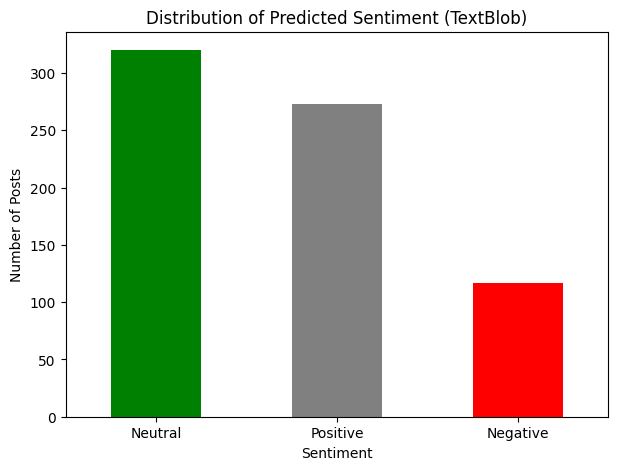

In [31]:
import matplotlib.pyplot as plt

# Count how many posts fall into each predicted sentiment category
sentiment_counts = df["predicted_sentiment"].value_counts()

plt.figure(figsize=(7, 5))
sentiment_counts.plot(kind="bar", color=["green", "gray", "red"])
plt.title("Distribution of Predicted Sentiment (TextBlob)")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)
plt.show()

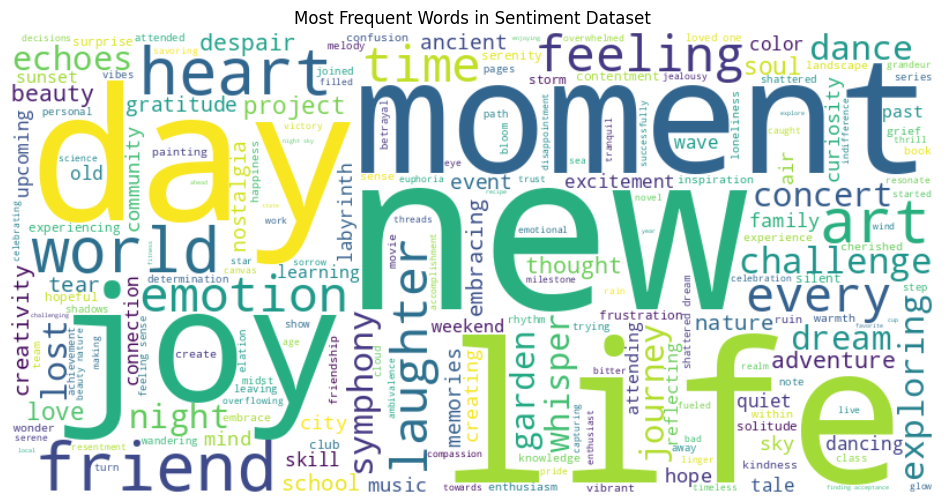

In [32]:
!pip install wordcloud --quiet
from wordcloud import WordCloud

# Combine all cleaned text into one big string
all_text = " ".join(df["clean_text"])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Sentiment Dataset")
plt.show()